In [ ]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Bank Marketing.csv")

In [ ]:
#SHAPE
print("Shape",df.shape)
#Features
print("Features",df.shape[1])
#Data Points
print("Data Points",len(df))

Shape (41188, 21)
Features 21
Data Points 41188


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
#Binary Classification Problem
print('Targeted Values',df['y'].unique())

Targeted Values ['no' 'yes']


In [ ]:
#Quantitative Columns
qunatitavive_cols=df.select_dtypes(include=['int64','float64']).columns
print("Quantitative Columns",qunatitavive_cols)
#Categorical Columns
categorical_cols=df.select_dtypes(include=['object']).columns
print("Categoprical Columns",categorical_cols)

Quantitative Columns Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')
Categoprical Columns Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')


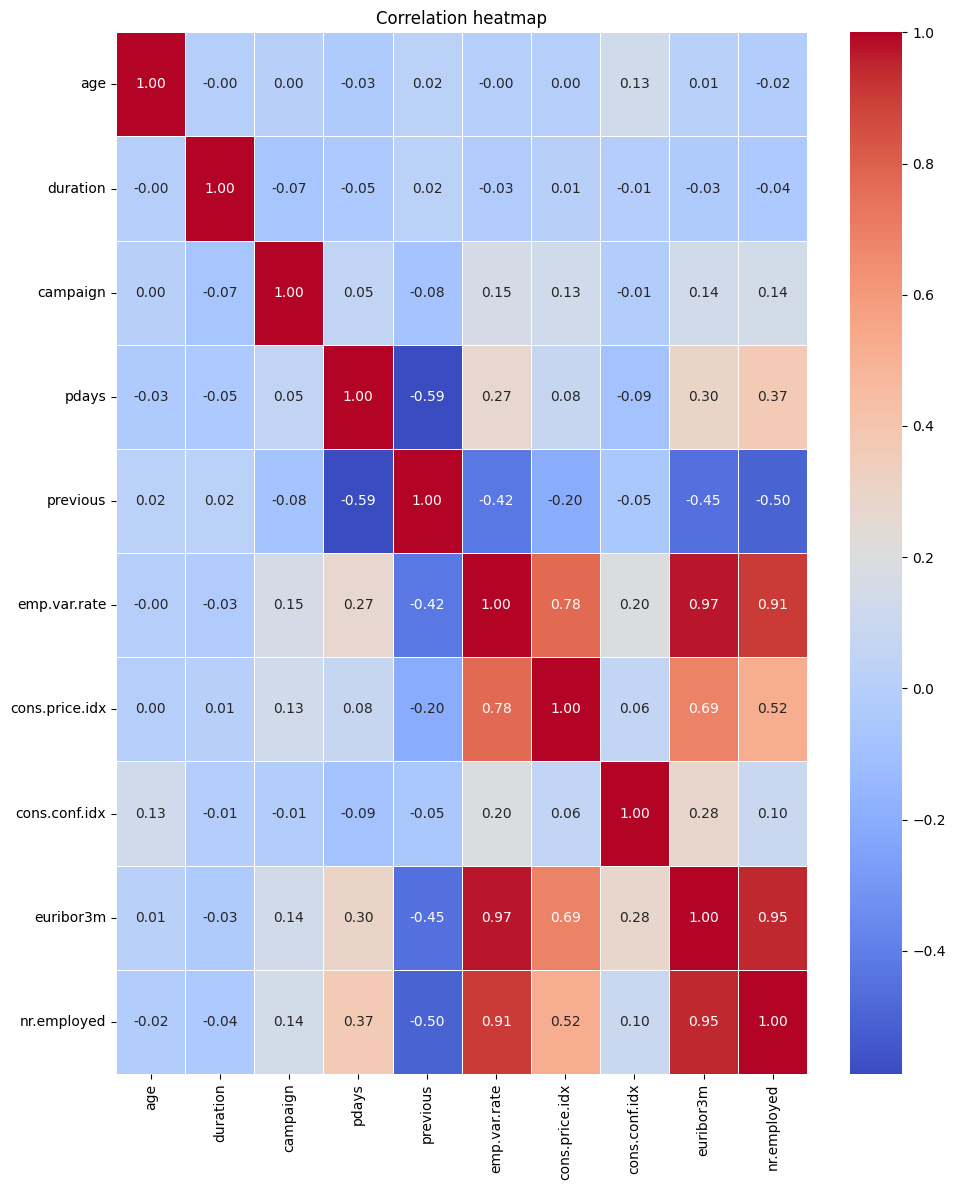

In [ ]:
plt.figure(figsize=(10,12))
correlation_matrix=df[qunatitavive_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

Class Distribution
For Yes: 4640 (11.27%)
For No: 36548 (88.73%)


/tmp/ipykernel_1128/3686085450.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['No', 'Yes'],


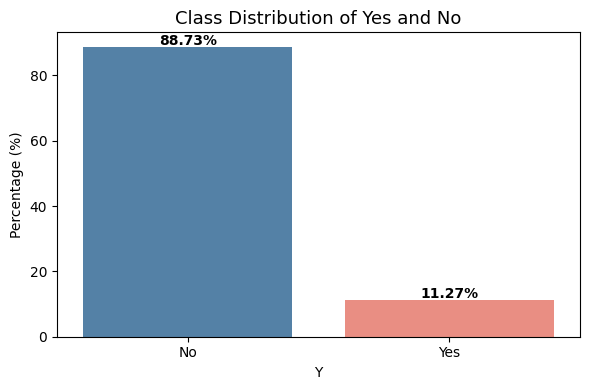

In [ ]:
# Class Imbalance Checking
imb_check = df['y'].value_counts()
imb_pct = df['y'].value_counts(normalize=True) * 100

print("Class Distribution")
print(f"For Yes: {imb_check[1]} ({imb_pct[1]:.2f}%)")
print(f"For No: {imb_check[0]} ({imb_pct[0]:.2f}%)")


plt.figure(figsize=(6, 4))
sns.barplot(x=['No', 'Yes'],
            y=[imb_pct[0], imb_pct[1]],
            palette=['steelblue', 'salmon'])

plt.title('Class Distribution of Yes and No', fontsize=13)
plt.ylabel('Percentage (%)')
plt.xlabel('Y')

for i, v in enumerate([imb_pct[0], imb_pct[1]]):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
#Checking missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
#Cheking nan vaslues
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
#Checking unknown keywords
(df=='unknown').sum()

,0
age,0
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0


In [ ]:
#Handling Unknown Values
df.replace('unknown',np.nan,inplace=True)

In [ ]:
#Checking again unknown keywords
(df=='unknown').sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
#Checking again missing values
df.isnull().sum()

,0
age,0
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0


In [ ]:
cat_cols = [col for col in categorical_cols if col != 'y']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
for col in qunatitavive_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1128/1848488024.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1128/1848488024.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
#Checking again missing values
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


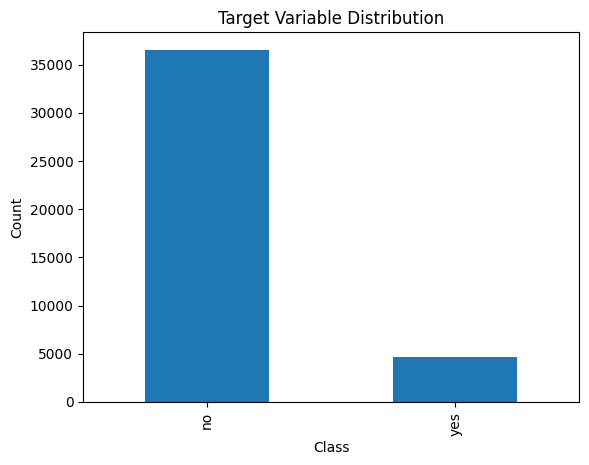

In [ ]:
#EDA
plt.figure()
df['y'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

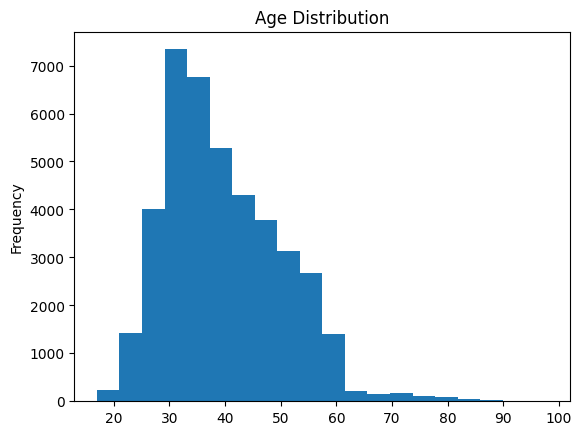

In [ ]:
df['age'].plot(kind='hist', bins=20)
plt.title("Age Distribution")
plt.show()

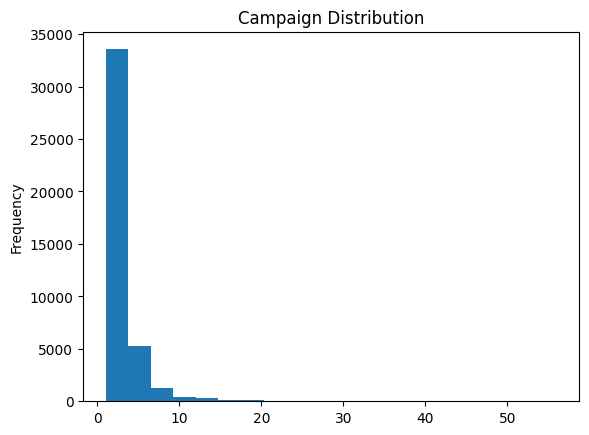

In [ ]:
df['campaign'].plot(kind='hist', bins=20)
plt.title("Campaign Distribution")
plt.show()

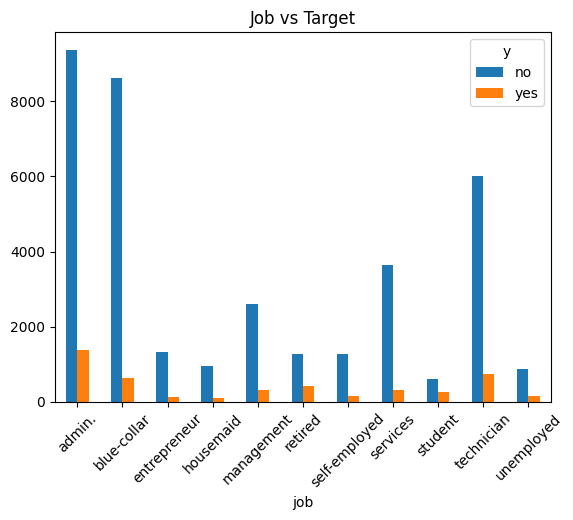

In [ ]:
pd.crosstab(df['job'], df['y']).plot(kind='bar')
plt.title("Job vs Target")
plt.xticks(rotation=45)
plt.show()

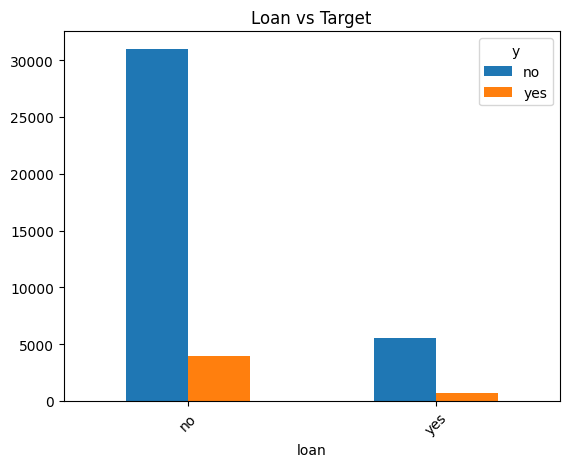

In [ ]:
pd.crosstab(df['loan'],df['y']).plot(kind='bar')
plt.title('Loan vs Target')
plt.xticks(rotation=45)
plt.show()

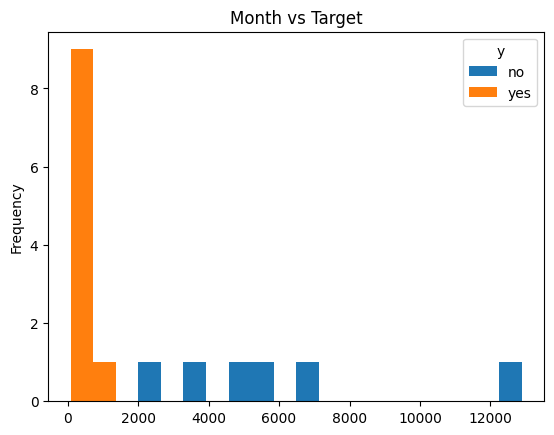

In [ ]:
pd.crosstab(df['month'],df['y']).plot(kind='hist', bins=20)
plt.title('Month vs Target')
plt.show()

/tmp/ipykernel_1128/1179775587.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


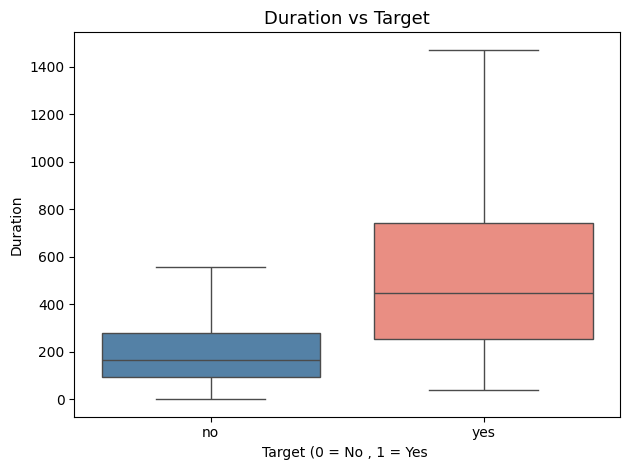

In [ ]:
sns.boxplot(
    x='y',
    y='duration',
    data=df,
    palette={'no': 'steelblue', 'yes': 'salmon'},
    showfliers=False
)
plt.title('Duration vs Target',fontsize=13)
plt.xlabel('Target (0 = No , 1 = Yes ')
plt.ylabel('Duration')
plt.tight_layout()
plt.show()

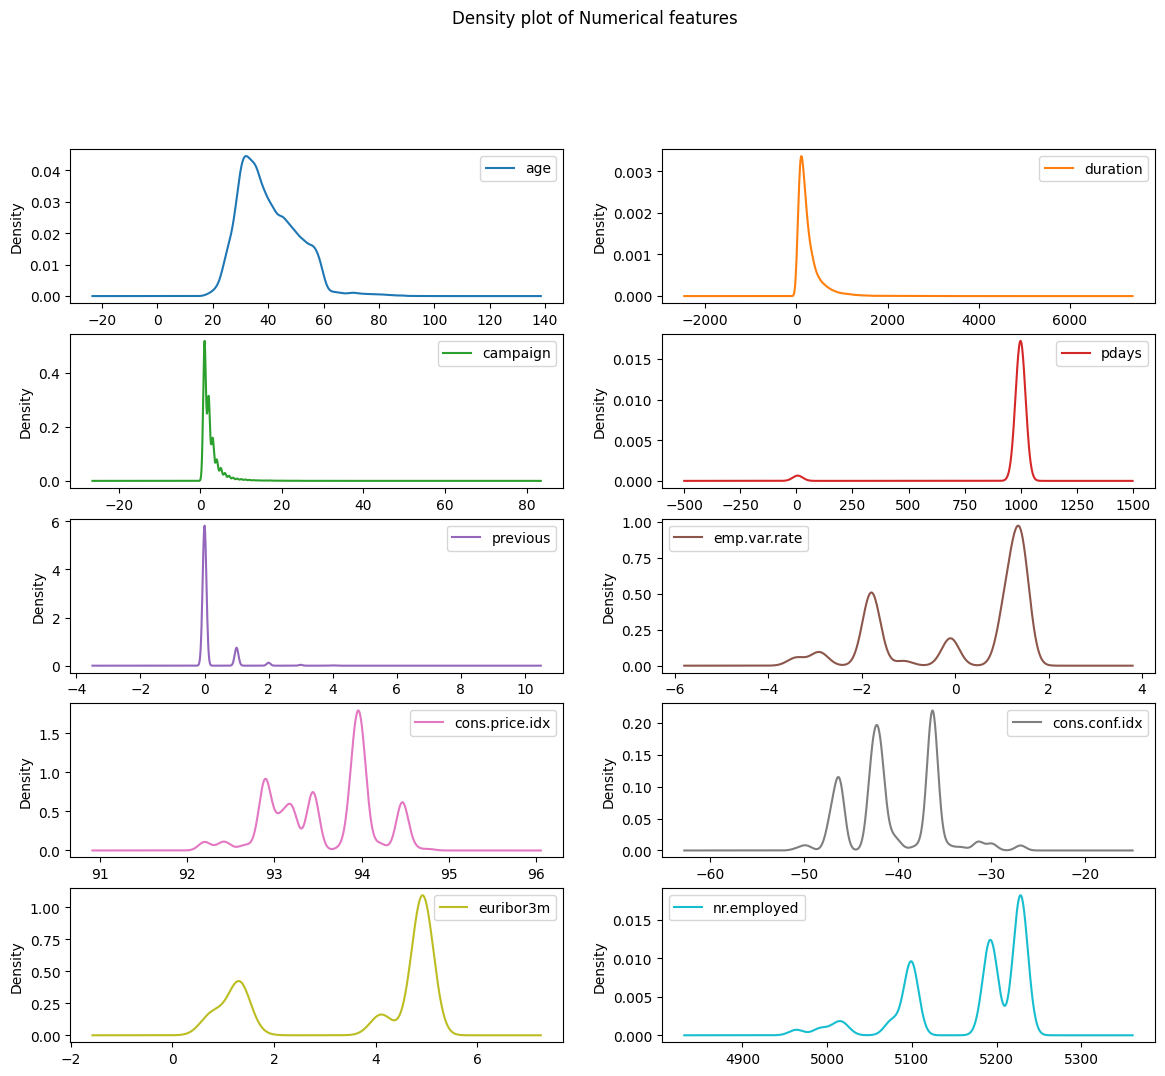

In [ ]:
df[qunatitavive_cols].plot(
    kind='density',
    figsize=(14, 14),
    subplots=True,
    layout=(6, 2),
    title="Density plot of Numerical features",
    sharex=False
)
plt.show()

In [ ]:
df['y'] = df['y'].map({'no': 0, 'yes': 1})

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [ ]:
#DROPPING IRRELEVANT COLUMNS
cols_to_drop = ['duration']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"Columns after dropping: {df.shape[1]}")
print(df.columns.tolist())

Columns after dropping: 20
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [ ]:
#SEPERATING FEATURES
X = df.drop('y', axis=1)
y = df['y']
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (41188, 19)
y shape: (41188,)


In [ ]:
#SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing set size  : {X_test.shape[0]} samples")
print("\nClass distribution in Train set:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nClass distribution in Test set:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set size : 32950 samples
Testing set size  : 8238 samples

Class distribution in Train set:
y
0    88.73
1    11.27
Name: proportion, dtype: float64

Class distribution in Test set:
y
0    88.74
1    11.26
Name: proportion, dtype: float64


In [ ]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=500, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8150036416605972
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      7310
           1       0.34      0.66      0.44       928

    accuracy                           0.82      8238
   macro avg       0.64      0.75      0.67      8238
weighted avg       0.88      0.82      0.84      8238



In [ ]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8964554503520272
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.58      0.28      0.38       928

    accuracy                           0.90      8238
   macro avg       0.75      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238



In [ ]:
#NAIVE BAYES
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.19422189851905802
              precision    recall  f1-score   support

           0       0.96      0.10      0.17      7310
           1       0.12      0.97      0.21       928

    accuracy                           0.19      8238
   macro avg       0.54      0.53      0.19      8238
weighted avg       0.87      0.19      0.18      8238



In [ ]:
#NLP
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=42
)
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)
print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

Neural Network Accuracy: 0.895241563486283
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.57      0.28      0.38       928

    accuracy                           0.90      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.88      0.90      0.88      8238



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


KMeans Accuracy (approx): 0.8873458288821987


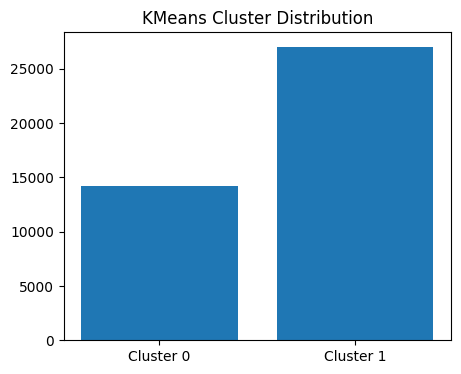


Cluster vs Target:
y          0     1
row_0             
0      10862  3326
1      25686  1314


In [ ]:
#K-MEANS
from sklearn.cluster import KMeans
from scipy.stats import mode
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_

mapped = np.zeros_like(cluster_labels)

for k in range(2):
    mask = cluster_labels == k
    mapped[mask] = mode(y.values[mask])[0]

from sklearn.metrics import accuracy_score

km_acc = accuracy_score(y, mapped)
print("KMeans Accuracy (approx):", km_acc)


unique, counts = np.unique(cluster_labels, return_counts=True)

plt.figure(figsize=(5, 4))
plt.bar([f'Cluster {u}' for u in unique], counts)
plt.title('KMeans Cluster Distribution')
plt.show()


print("\nCluster vs Target:")
print(pd.crosstab(cluster_labels, y))

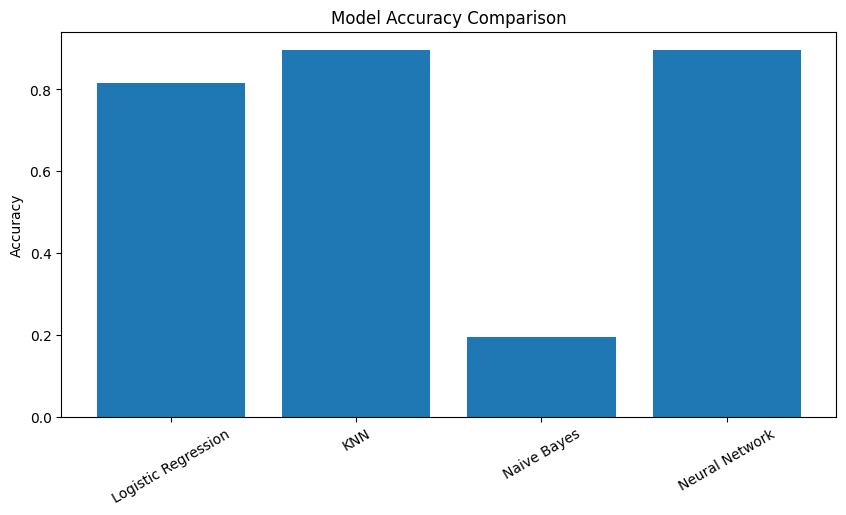

In [ ]:
#ACCURACY COMPARISON OF MODELS
results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'Neural Network': accuracy_score(y_test, y_pred_mlp)
}
plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

                     Precision    Recall  F1-Score
Model                                             
Logistic Regression   0.335541  0.655172  0.443796
KNN                   0.583149  0.283405  0.381436
Naive Bayes           0.119739  0.968750  0.213134
Neural Network        0.570806  0.282328  0.377794


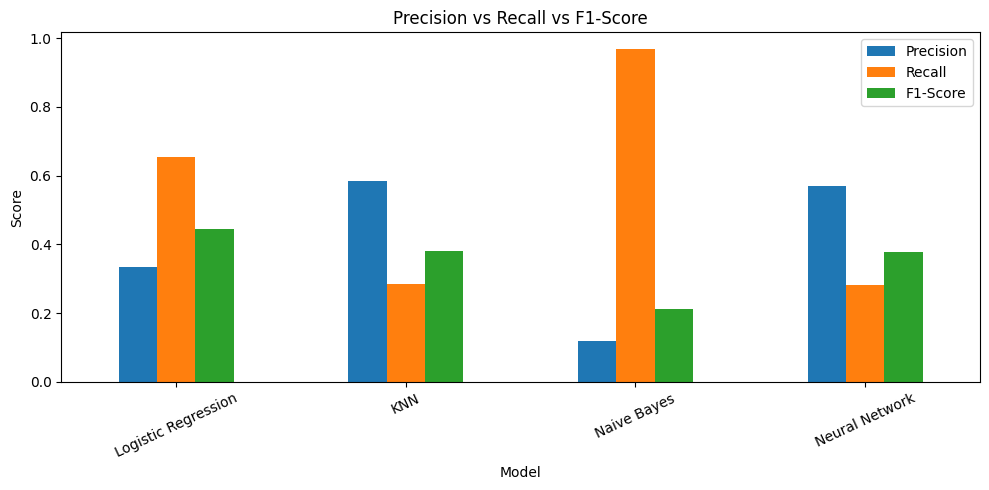

In [ ]:
#PRECISION RECALL F-1 SCORE
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_data = []

models_preds = {
    'Logistic Regression': y_pred_lr,
    'KNN': y_pred_knn,
    'Naive Bayes': y_pred_nb,
    'Neural Network': y_pred_mlp
}

for name, preds in models_preds.items():
    comparison_data.append({
        'Model': name,
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0)
    })

comparison_df = pd.DataFrame(comparison_data).set_index('Model')

print(comparison_df)


comparison_df.plot(kind='bar', figsize=(10,5))
plt.title("Precision vs Recall vs F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

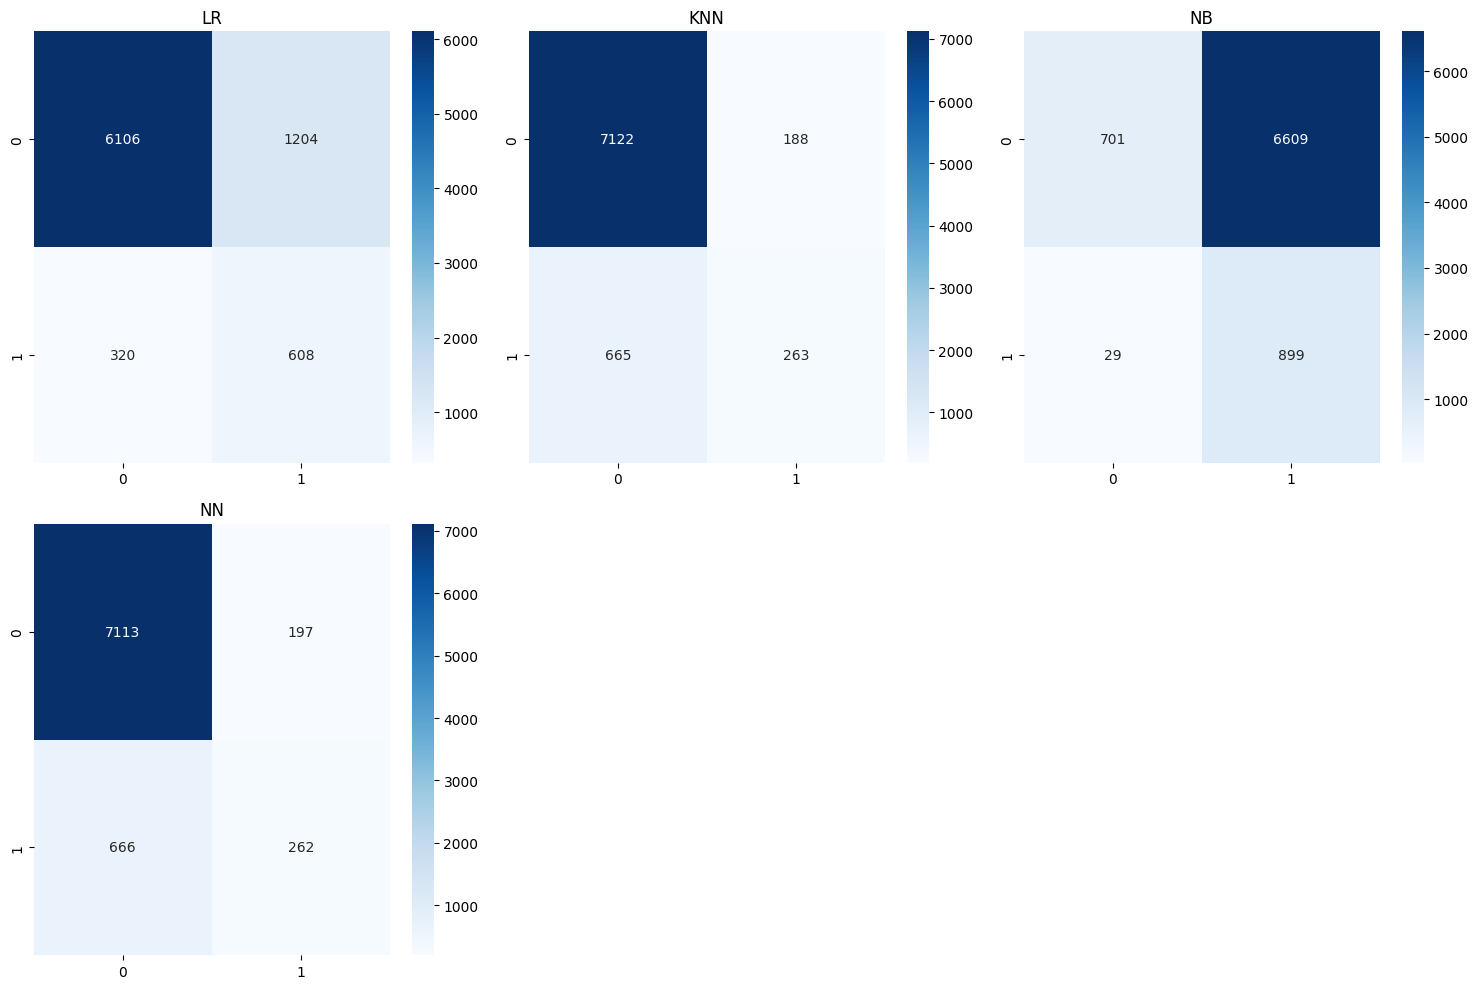

In [ ]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix
import seaborn as sns
models = {
    'LR': y_pred_lr,
    'KNN': y_pred_knn,
    'NB': y_pred_nb,
    'NN': y_pred_mlp
}
plt.figure(figsize=(15,10))

for i, (name, preds) in enumerate(models.items()):
    plt.subplot(2,3,i+1)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)

plt.tight_layout()
plt.show()

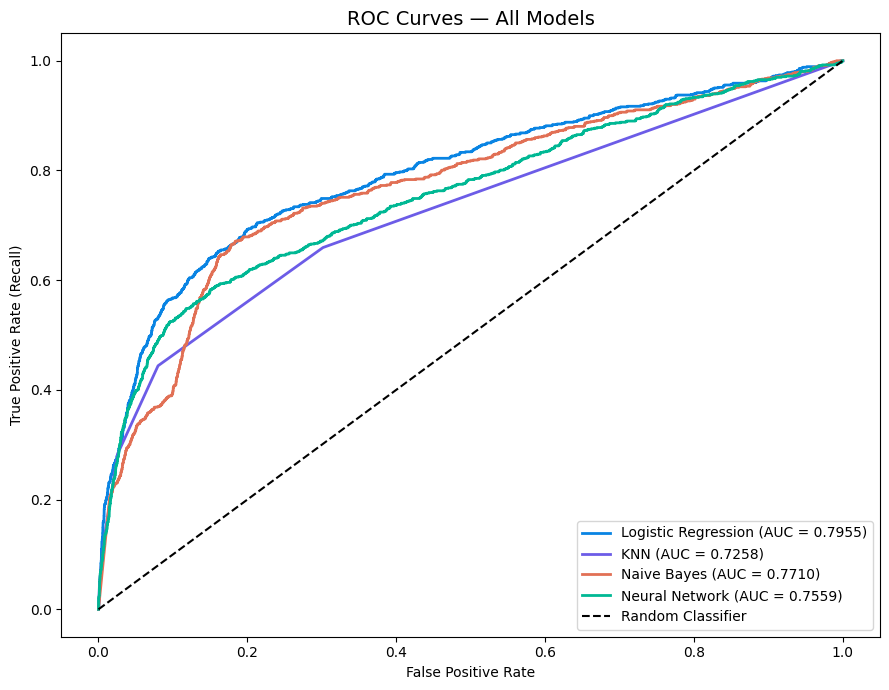


AUC Scores:
Logistic Regression: 0.7955
KNN: 0.7258
Naive Bayes: 0.7710
Neural Network: 0.7559


In [ ]:
#ROC AND AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

model_objects = {
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'Naive Bayes': nb_model,
    'Neural Network': mlp_model
}

colors = ['#0984e3', '#6c5ce7', '#e17055', '#00b894', '#e84393']

auc_scores = {}

for (name, model), color in zip(model_objects.items(), colors):


    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_scores = model.decision_function(X_test)
    else:
        continue

    # ROC values
    fpr, tpr, _ = roc_curve(y_test, y_scores)

    # AUC
    auc_score = roc_auc_score(y_test, y_scores)
    auc_scores[name] = auc_score

    # Plot
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {auc_score:.4f})')


plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')

plt.title('ROC Curves — All Models', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nAUC Scores:")
for name, score in auc_scores.items():
    print(f"{name}: {score:.4f}")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

summary_rows = []

for name, model in model_objects.items():

    preds = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)

    summary_rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall': round(recall_score(y_test, preds, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, preds, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_test, scores), 4)
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
summary_df = summary_df.sort_values('AUC-ROC', ascending=False)

print(summary_df.to_string())

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.8150     0.3355  0.6552    0.4438   0.7955
Naive Bayes            0.1942     0.1197  0.9688    0.2131   0.7710
Neural Network         0.8952     0.5708  0.2823    0.3778   0.7559
KNN                    0.8965     0.5831  0.2834    0.3814   0.7258
